# Regression Analysis

## Gym Members Exercise Dataset

**Author:** Sarah Suliman  
**Course:** CSPB 4502: Data Mining  
**Project:** Discovering Fitness Profiles and Workout Performance Patterns Through Data Mining

## 1. Objective

The objective of this notebook is to predict the number of calories burned during a workout session using demographic characteristics, physiological measurements, and workout-related features.

Three regression models will be evaluated:

- Baseline Regressor
- Linear Regression
- Random Forest Regressor

Model performance will be compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²).

In [19]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [20]:
DATA_PATH = Path("../data/processed/gym_members_exercise_cleaned.csv")
FIGURES_DIR = Path("../figures")
MODELS_DIR = Path("../models")

df = pd.read_csv(DATA_PATH)

df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Heart_Rate_Reserve,Calories_Per_Hour,Water_Intake_Per_Hour,BMI_Category
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20,120,776.923077,2.071006,Obese
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00,113,679.230769,1.615385,Obese
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71,113,609.909910,2.072072,Normal
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41,134,901.694915,3.559322,Underweight
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39,120,868.750000,4.375000,Underweight


## 2. Define Features and Target

In [21]:
TARGET = "Calories_Burned"

numeric_features = [
    "Age",
    "Weight (kg)",
    "Height (m)",
    "BMI",
    "Max_BPM",
    "Avg_BPM",
    "Resting_BPM",
    "Heart_Rate_Reserve",
    "Session_Duration (hours)",
    "Fat_Percentage",
    "Water_Intake (liters)",
    "Workout_Frequency (days/week)"
]

categorical_features = [
    "Gender",
    "Workout_Type"
]

features = numeric_features + categorical_features

X = df[features]
y = df[TARGET]

The response variable is **Calories Burned**. Predictor variables include demographic characteristics, body composition, heart-rate measurements, hydration, workout frequency, and workout type.

## 3. Train/Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(f"Training observations: {len(X_train)}")
print(f"Testing observations: {len(X_test)}")

Training observations: 778
Testing observations: 195


## 4. Data Preprocessing

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

Continuous variables are standardized while categorical variables are transformed using one-hot encoding.

## 5. Baseline Regression Model

In [24]:
baseline = DummyRegressor(strategy="mean")

baseline.fit(X_train, y_train)

baseline_predictions = baseline.predict(X_test)

## 6. Linear Regression

In [25]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

## 7. Random Forest Regression

In [26]:
forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

forest_model.fit(X_train, y_train)

forest_predictions = forest_model.predict(X_test)

## 8. Compare Model Performance

In [27]:
results = pd.DataFrame(
    {
        "Model": [
            "Baseline",
            "Linear Regression",
            "Random Forest"
        ],
        "MAE": [
            mean_absolute_error(y_test, baseline_predictions),
            mean_absolute_error(y_test, linear_predictions),
            mean_absolute_error(y_test, forest_predictions),
        ],
        "RMSE": [
            np.sqrt(mean_squared_error(y_test, baseline_predictions)),
            np.sqrt(mean_squared_error(y_test, linear_predictions)),
            np.sqrt(mean_squared_error(y_test, forest_predictions)),
        ],
        "R2": [
            r2_score(y_test, baseline_predictions),
            r2_score(y_test, linear_predictions),
            r2_score(y_test, forest_predictions),
        ]
    }
)

results.round(3)

,Model,MAE,RMSE,R2
0,Baseline,231.205,288.918,-0.001
1,Linear Regression,30.257,40.534,0.980
2,Random Forest,36.666,48.701,0.972


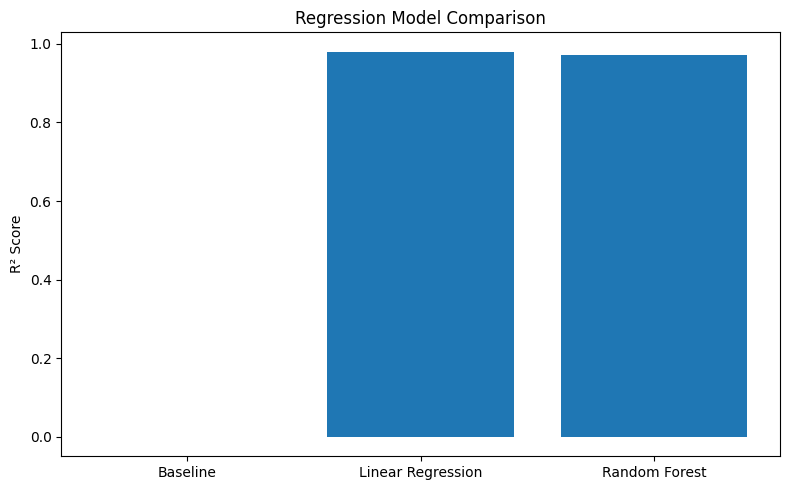

In [28]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["R2"]
)

plt.ylabel("R² Score")
plt.title("Regression Model Comparison")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "regression_model_comparison.png",
    dpi=300
)

plt.show()

The comparison demonstrates that both machine learning models substantially outperform the baseline model. Linear Regression achieved the highest R² value, indicating the strongest predictive performance for this dataset.

## 9. Actual vs Predicted Values

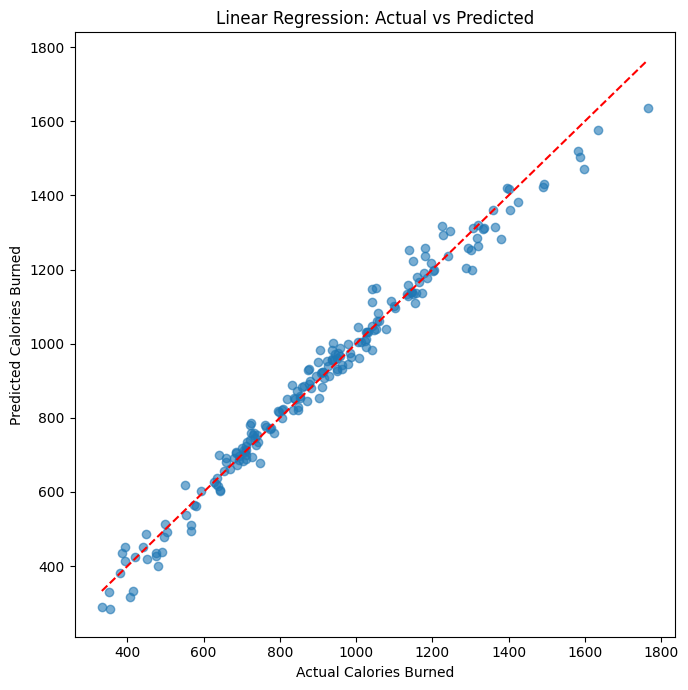

In [29]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    linear_predictions,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual Calories Burned")
plt.ylabel("Predicted Calories Burned")

plt.title("Linear Regression: Actual vs Predicted")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "linear_regression_actual_vs_predicted.png",
    dpi=300
)

plt.show()

The scatter plot shows that the predicted values closely follow the ideal 45-degree reference line, indicating strong agreement between the observed and predicted calorie expenditure.

## 10. Residual Analysis

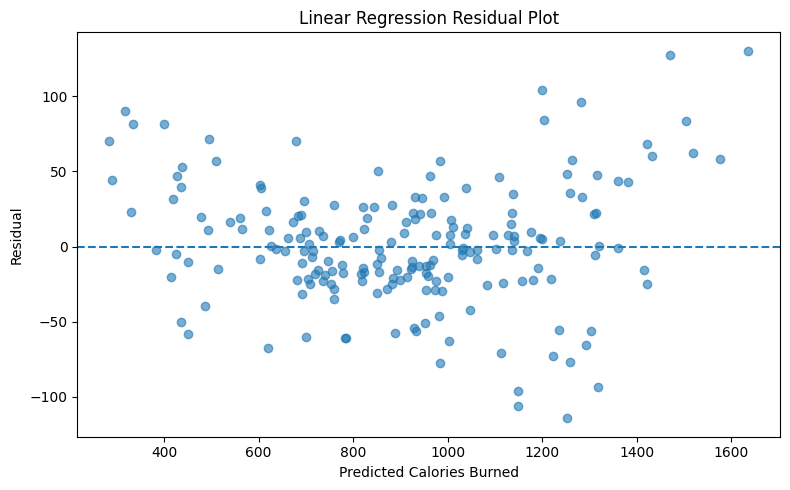

In [30]:
residuals = y_test - linear_predictions

plt.figure(figsize=(8,5))

plt.scatter(
    linear_predictions,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Calories Burned")
plt.ylabel("Residual")

plt.title("Linear Regression Residual Plot")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "linear_regression_residual_plot.png",
    dpi=300
)

plt.show()

Residuals are randomly distributed around zero, suggesting that the linear regression model provides an appropriate fit for the relationship between the predictors and calories burned.

## 11. Save Models

In [31]:
joblib.dump(
    linear_model,
    MODELS_DIR / "linear_regression_model.joblib"
)

joblib.dump(
    forest_model,
    MODELS_DIR / "random_forest_regression.joblib"
)

print("Regression models saved successfully.")

Regression models saved successfully.


## 12. Key Findings

The regression analysis compared a baseline model with Linear Regression and Random Forest regression. Linear Regression achieved the strongest predictive performance with the lowest prediction error and the highest R² value. The results indicate that demographic characteristics, physiological measurements, and workout behavior explain a large proportion of the variation in calories burned during exercise sessions. These findings suggest that calorie expenditure can be accurately estimated using commonly collected fitness variables.